In [1]:
# Core imports
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer
from scipy.stats import loguniform, randint, uniform


import matplotlib.pyplot as plt
import seaborn as sns


from xgboost import XGBClassifier

C:\Users\MAST\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
def load_data(history_path, current_path):
    """
    Load historical labeled claims and current unlabeled claims.
    """
    history_df = pd.read_csv(history_path)
    current_df = pd.read_csv(current_path)

    return history_df, current_df

In [3]:
TARGET_COL = "is_denied"

LEAKAGE_AND_ID_COLS = {
    "claim_id",
    "split",
    "is_denied",
    "denial_reason",
}

CATEGORICAL_COLS = [
    "payer_id",
    "payer_type",
    "visit_type",
    "service_month",
]

In [4]:
def get_feature_columns(history_df):
    """
    Select valid model input columns and exclude identifiers/leakage columns.
    """
    return [
        col for col in history_df.columns
        if col not in LEAKAGE_AND_ID_COLS
    ]

In [5]:
def coerce_feature_types(df, feature_cols):
    """
    Force non-categorical feature columns to numeric.

    This is needed because the CSV values are quoted, and some numeric columns
    may be read as object/string depending on the environment.
    """
    df = df.copy()

    for col in feature_cols:
        if col not in CATEGORICAL_COLS:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [6]:
def add_engineered_features(df):
    """
    Add claim-level engineered features.

    These features capture business-relevant combinations that are more
    meaningful than the raw fields alone, such as authorization missing only
    when authorization is actually required.
    """
    df = df.copy()

    df["auth_missing_when_required"] = (
        (df["prior_auth_required"] == 1) &
        (df["has_prior_auth"] == 0)
    ).astype(int)

    df["referral_missing_when_required"] = (
        (df["referral_required"] == 1) &
        (df["referral_present"] == 0)
    ).astype(int)

    df["payment_to_billed_ratio"] = (
        df["expected_payment"] / df["total_billed"].replace(0, np.nan)
    )

    df["billed_minus_expected"] = (
        df["total_billed"] - df["expected_payment"]
    )

    df["late_submission_30d"] = (
        df["days_to_submit"] >= 30
    ).astype(int)

    df["complex_claim"] = (
        (df["num_procedures"] >= 6) |
        (df["num_diagnoses"] >= 7)
    ).astype(int)

    df["admin_issue_count"] = (
        df["auth_missing_when_required"] +
        df["referral_missing_when_required"] +
        (df["missing_documentation_flag"] == 1).astype(int) +
        (df["eligibility_verified"] == 0).astype(int) +
        (df["is_in_network"] == 0).astype(int) +
        df["late_submission_30d"]
    )

    return df

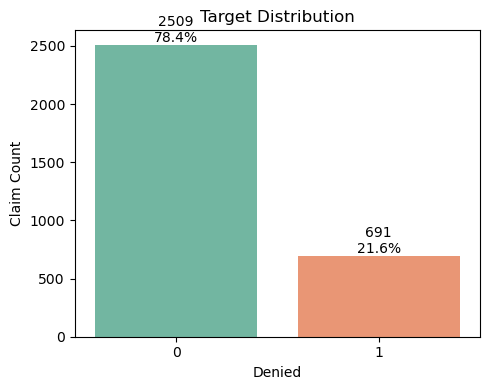

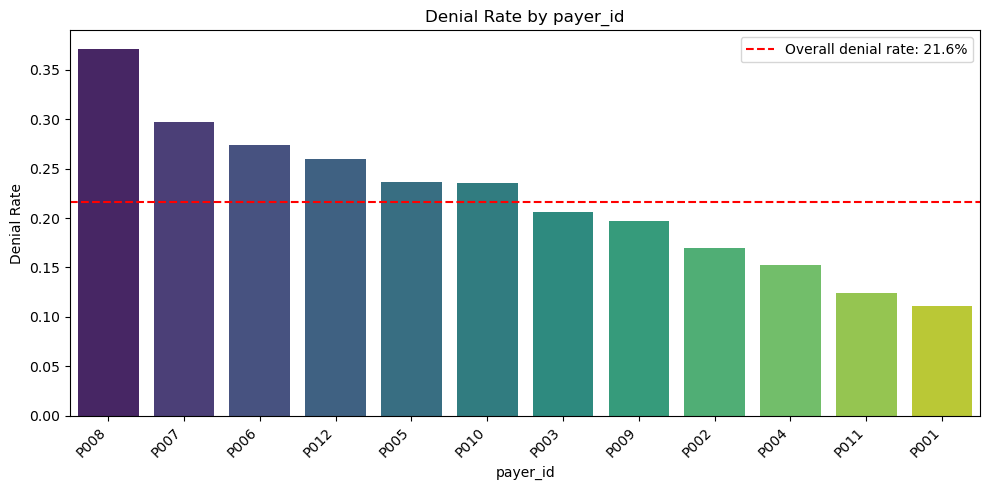

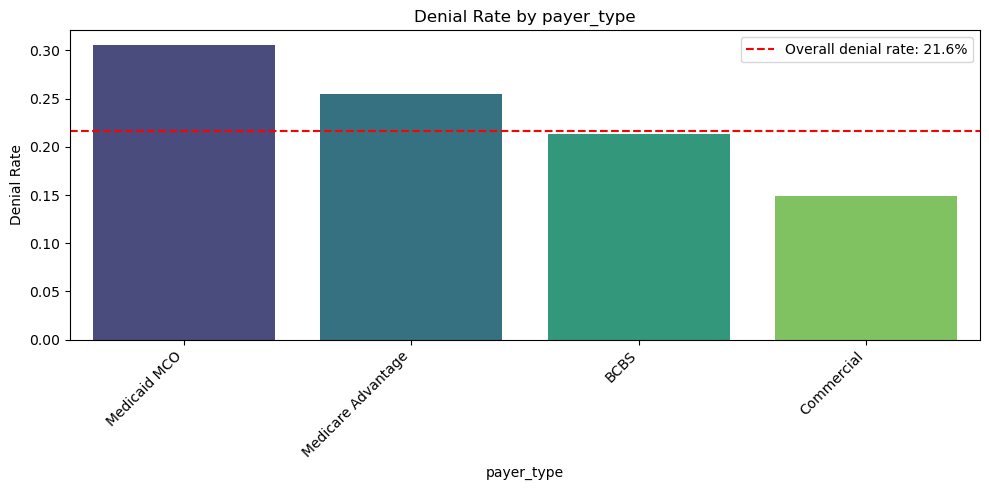

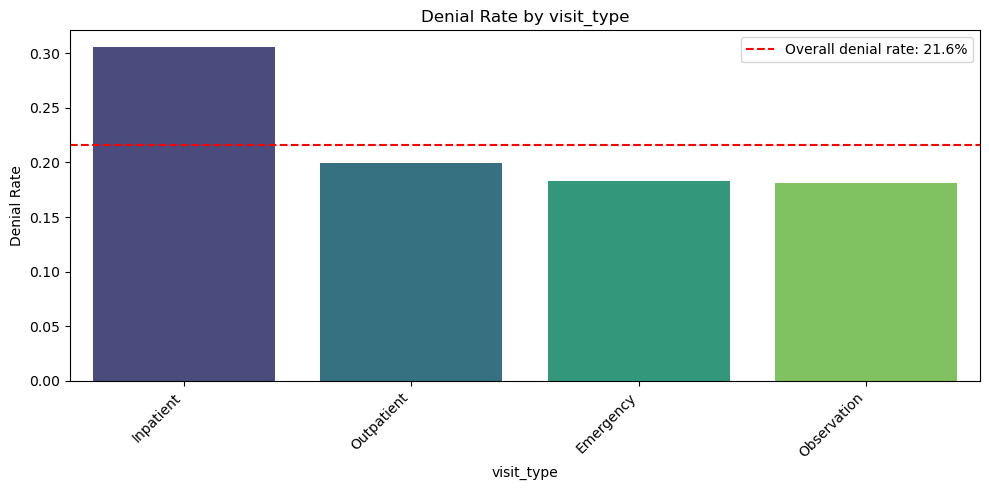

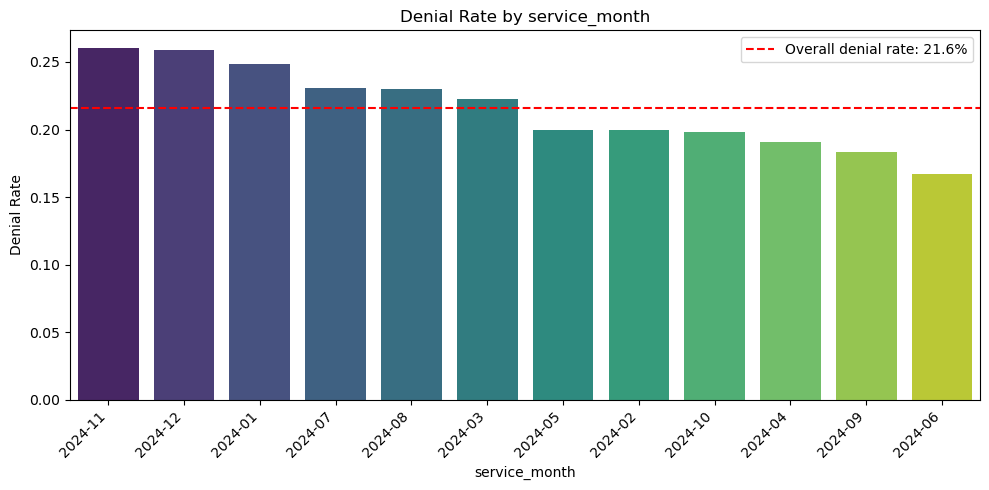

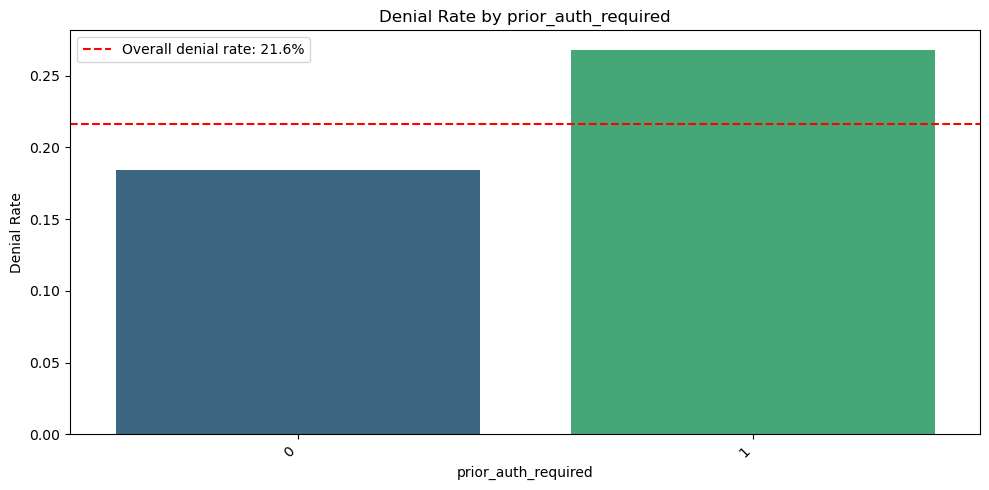

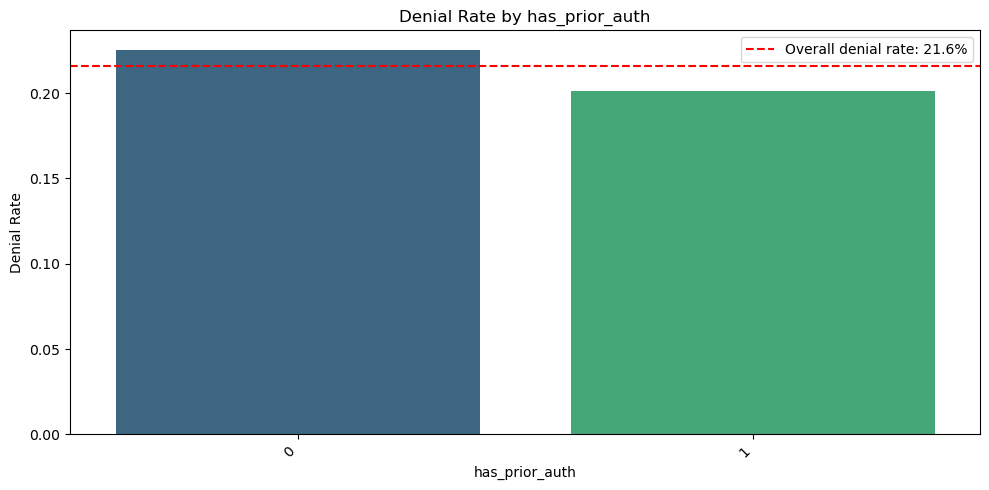

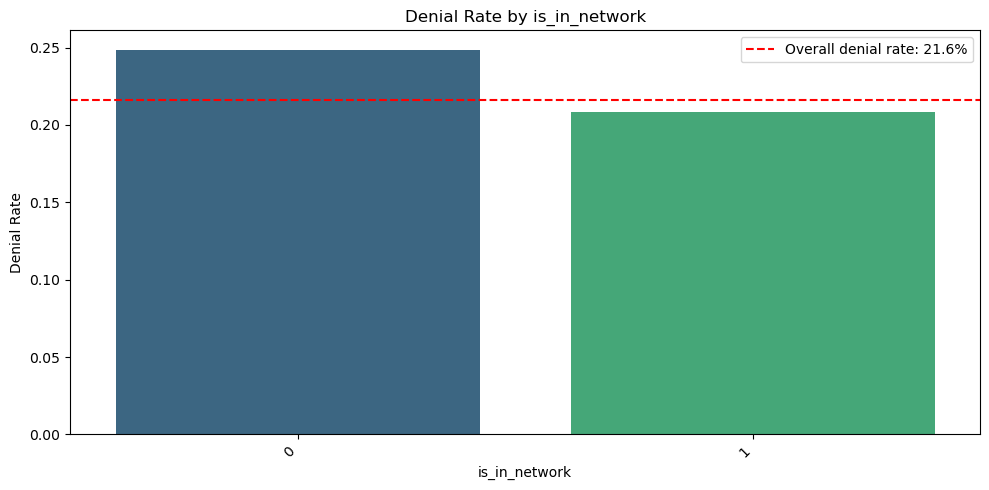

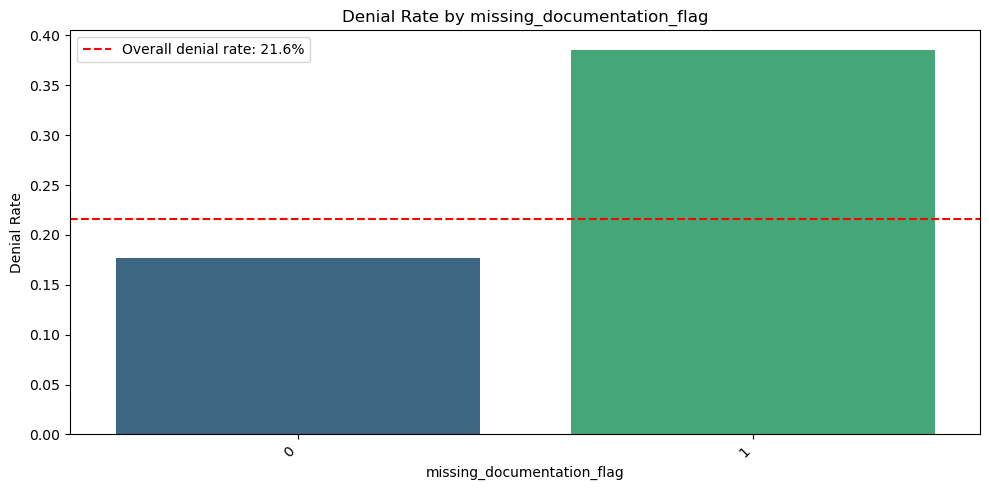

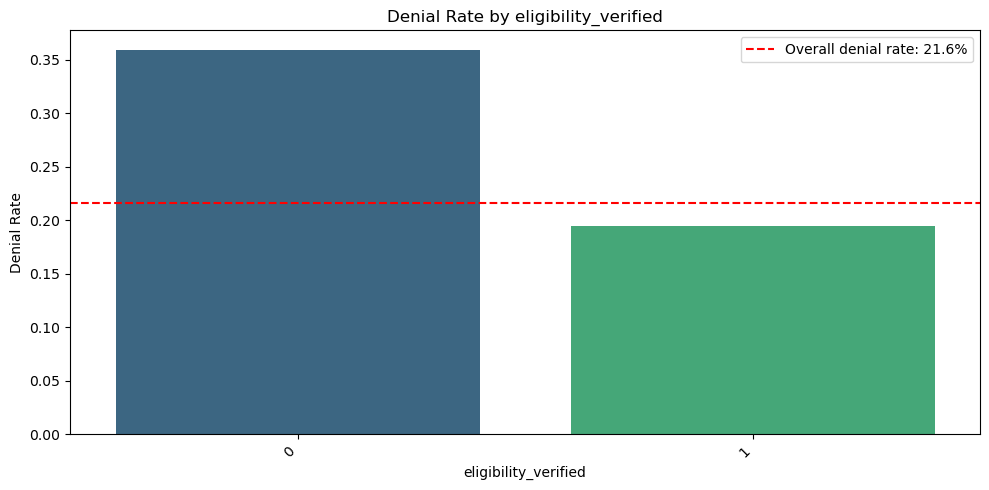

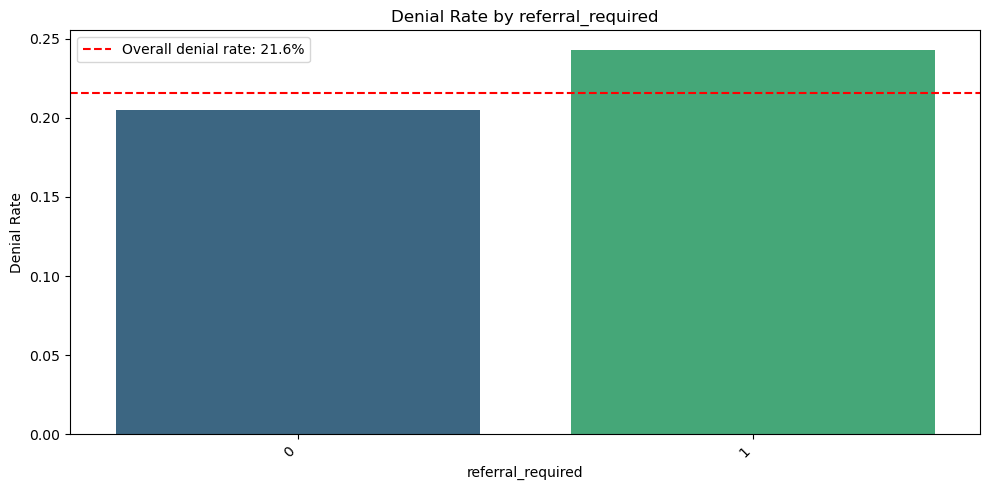

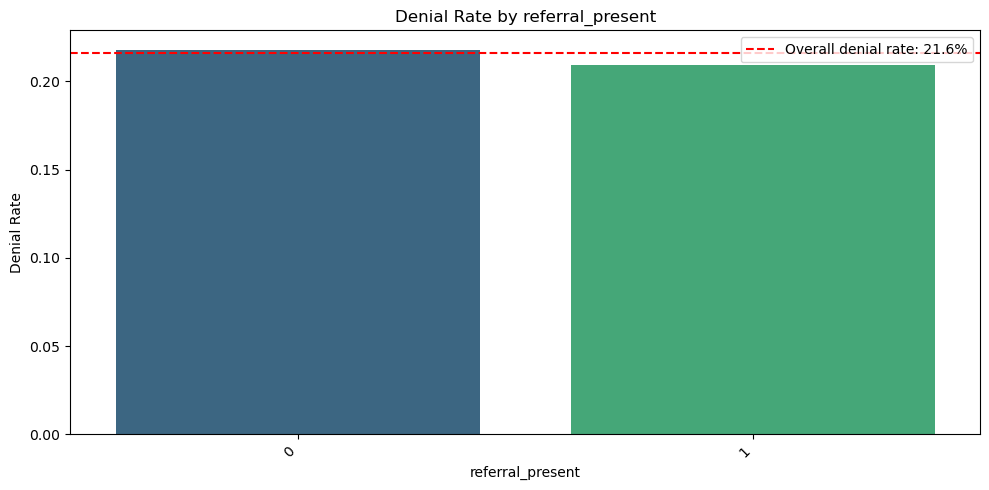

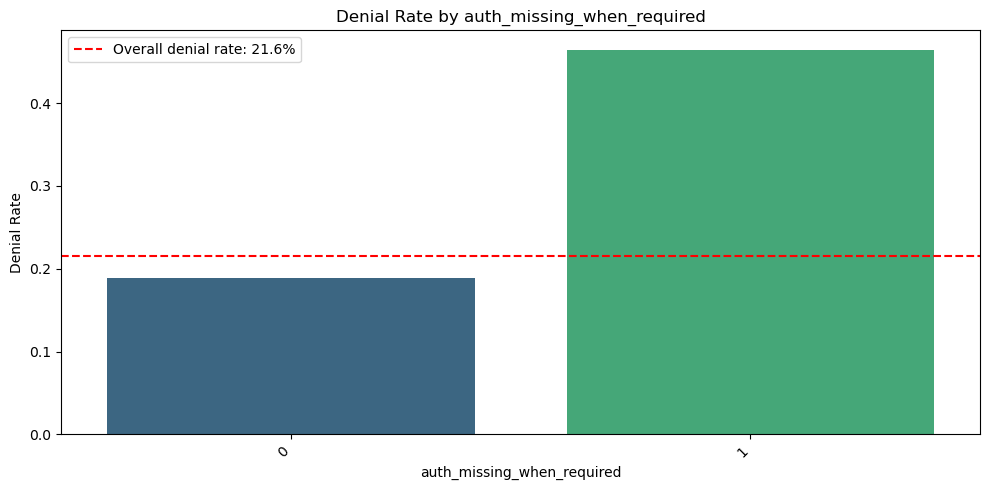

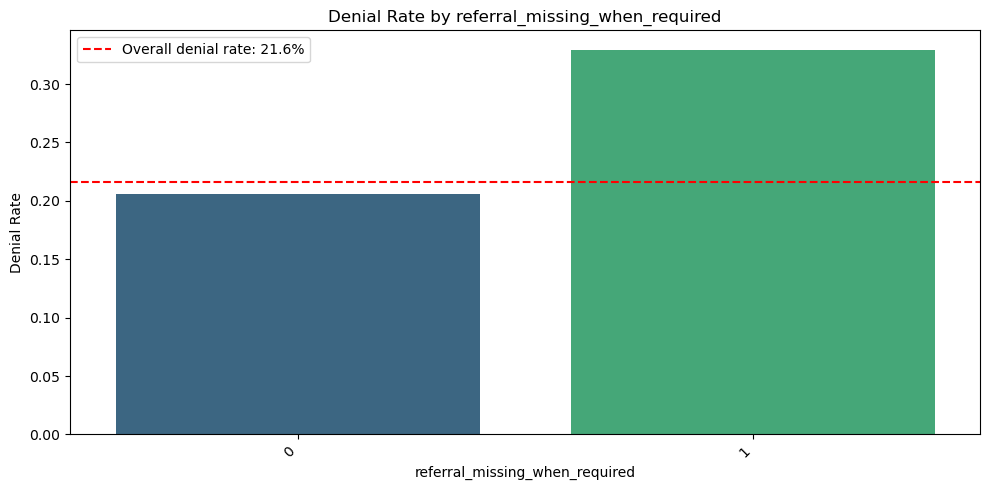

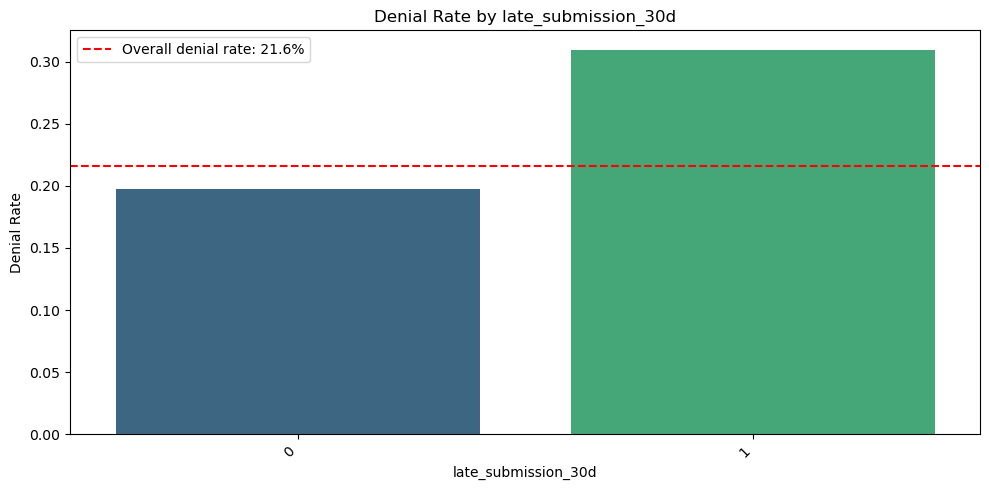

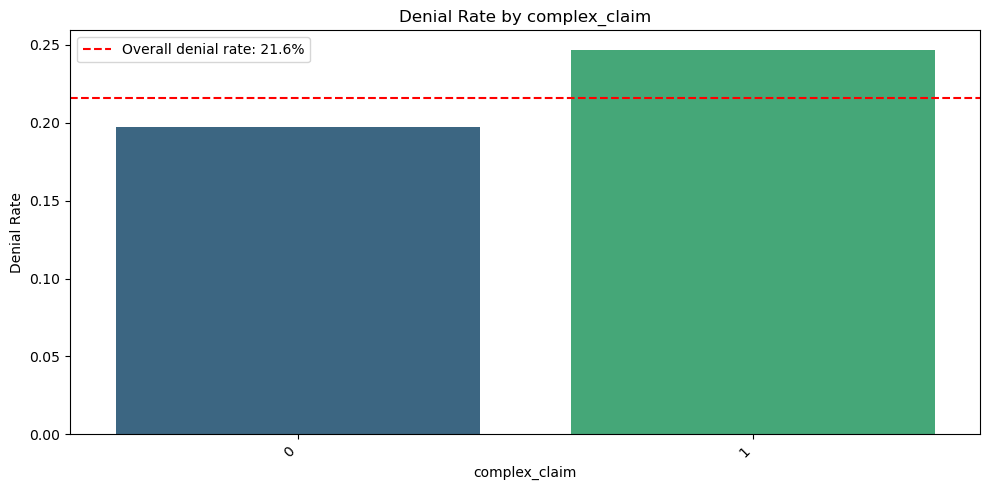

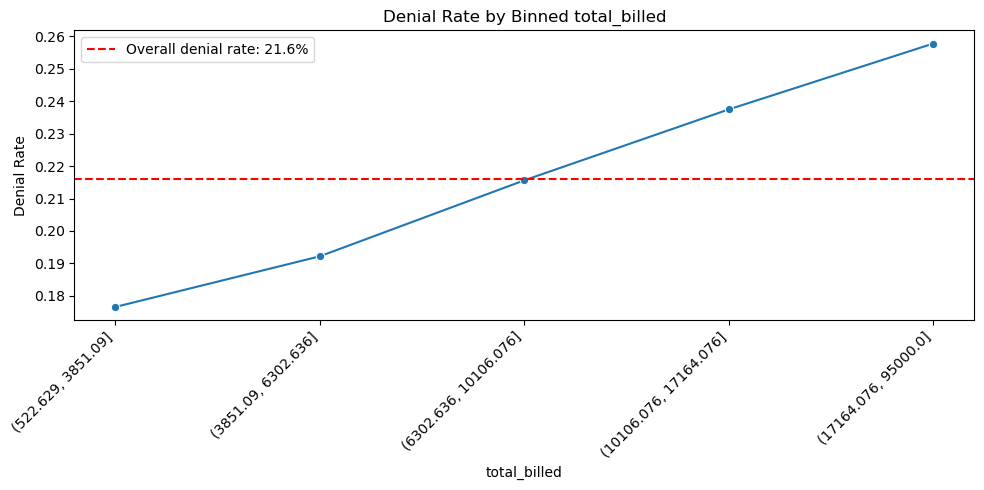

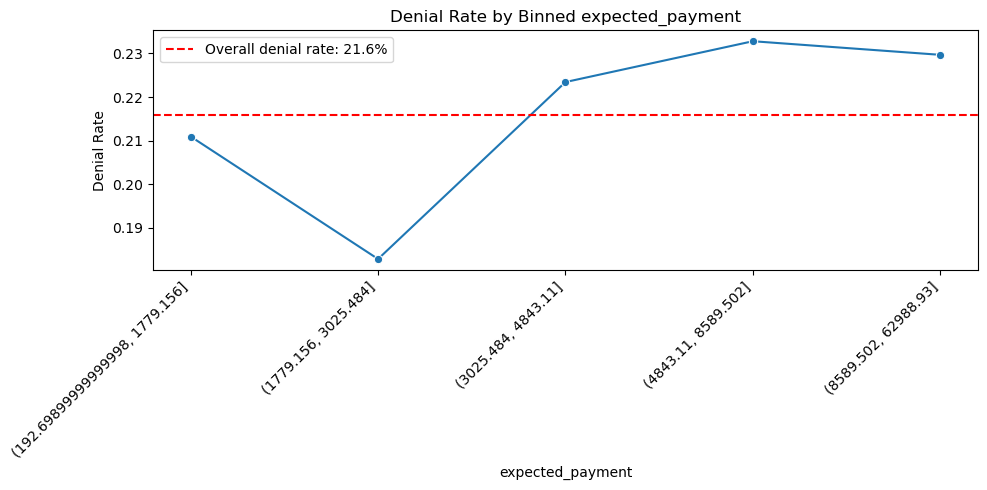

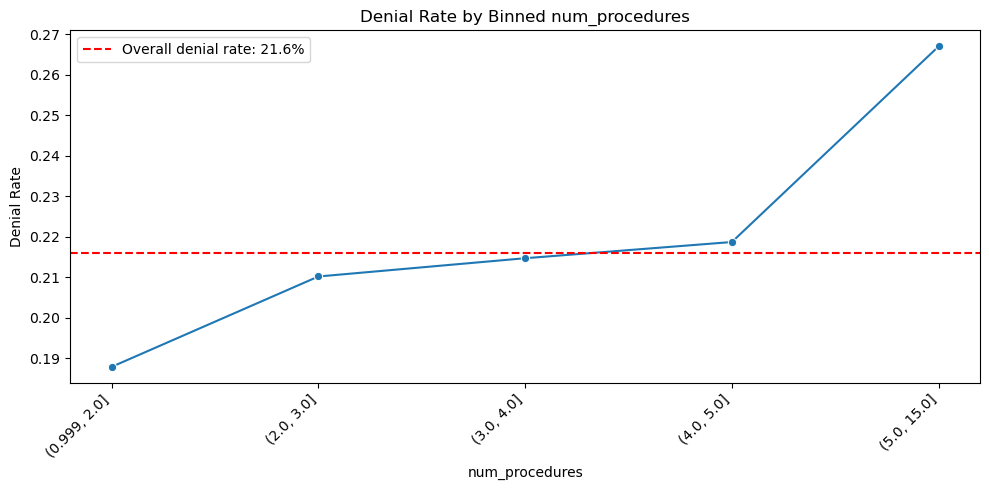

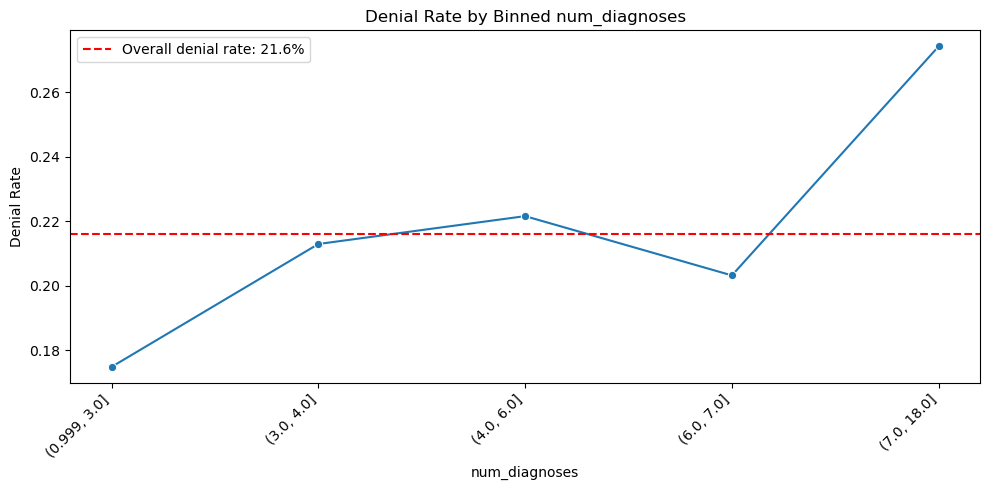

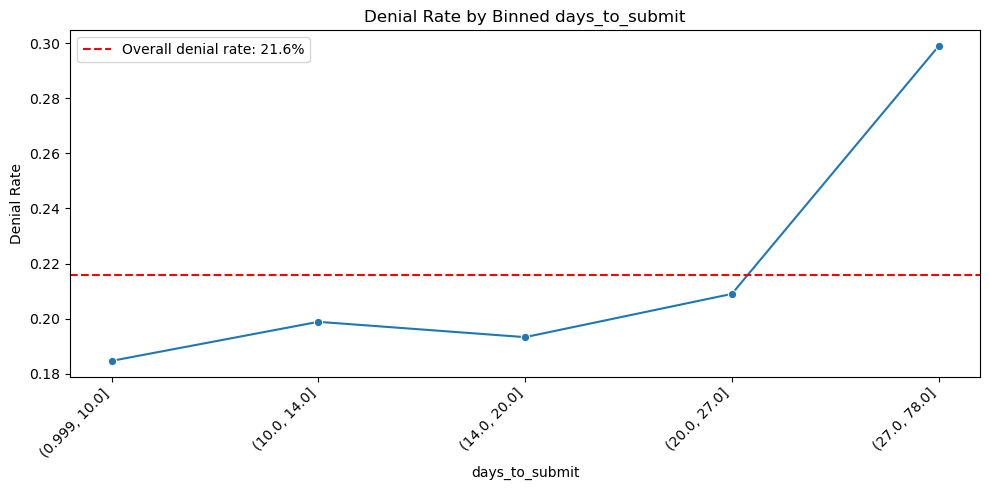

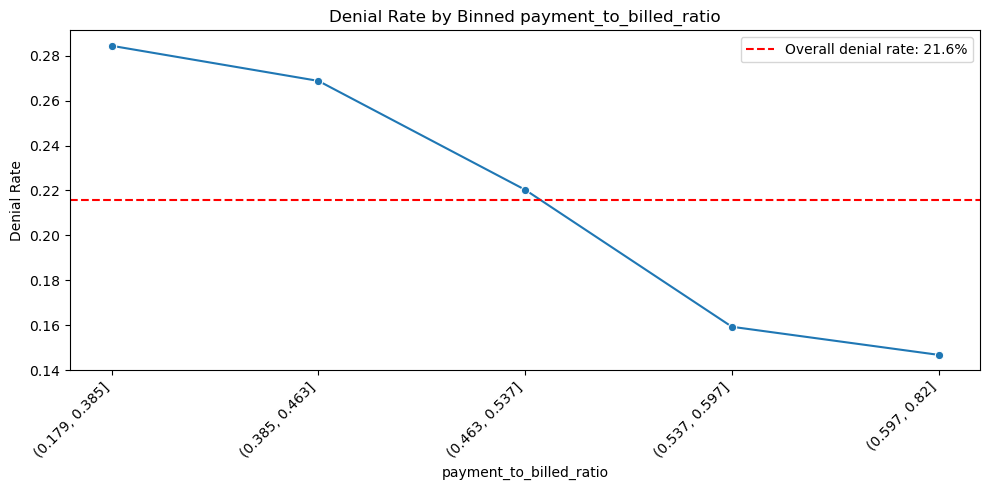

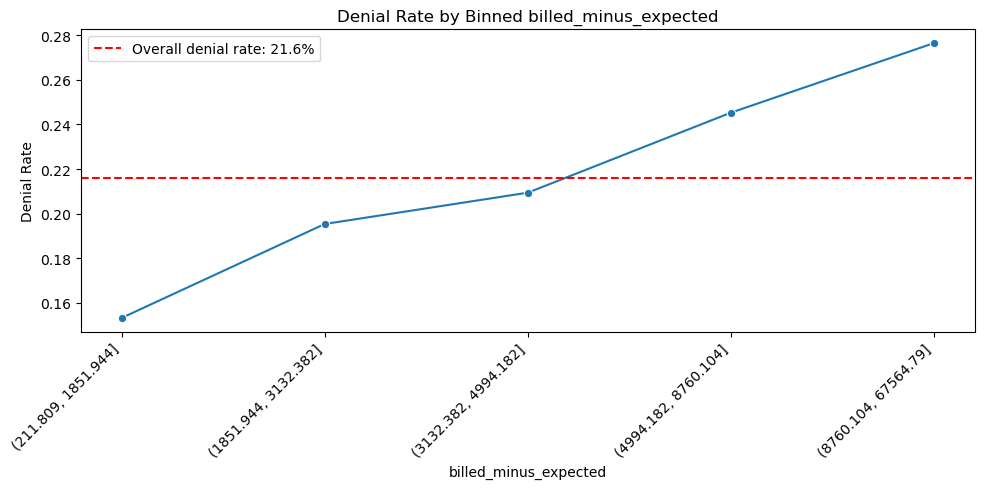

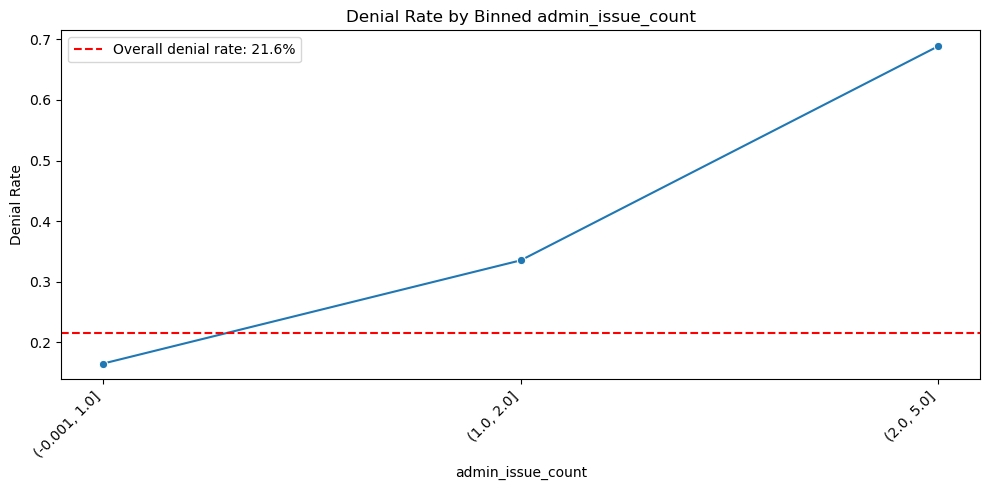

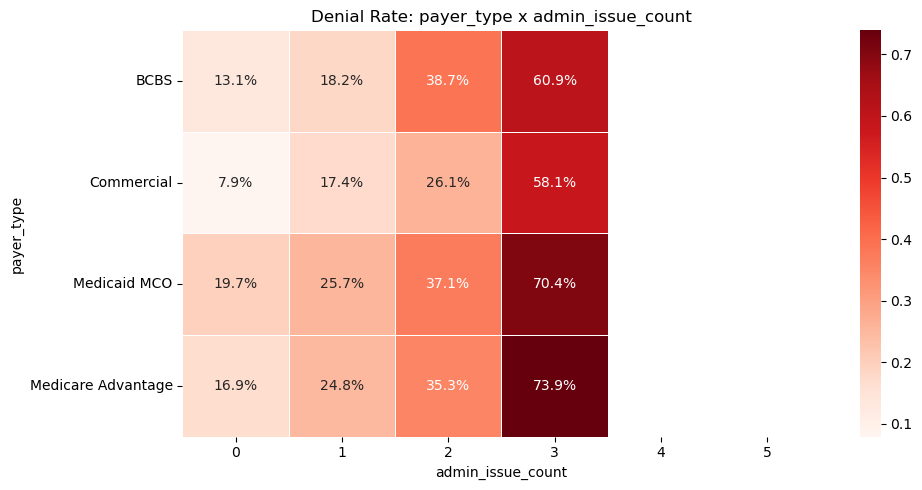

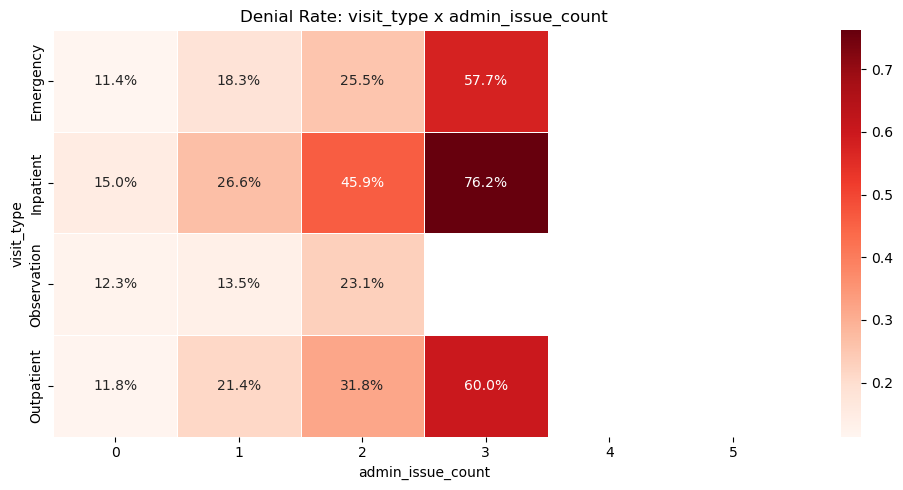

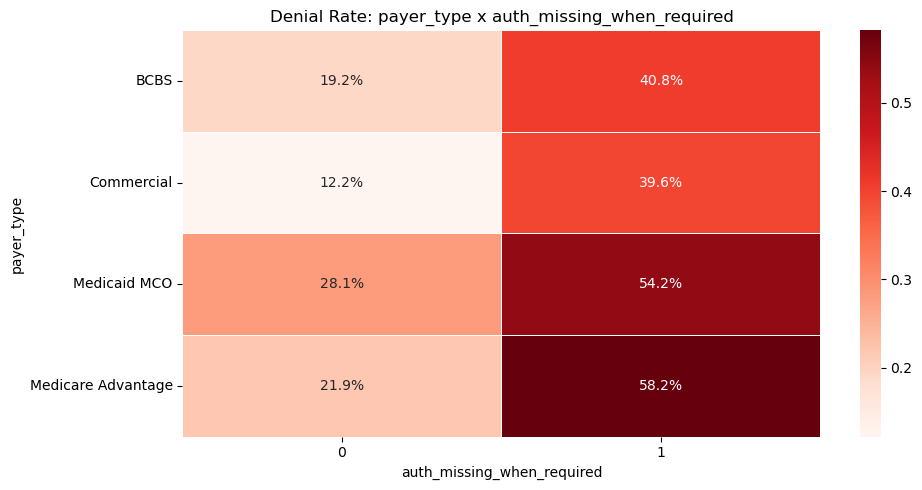

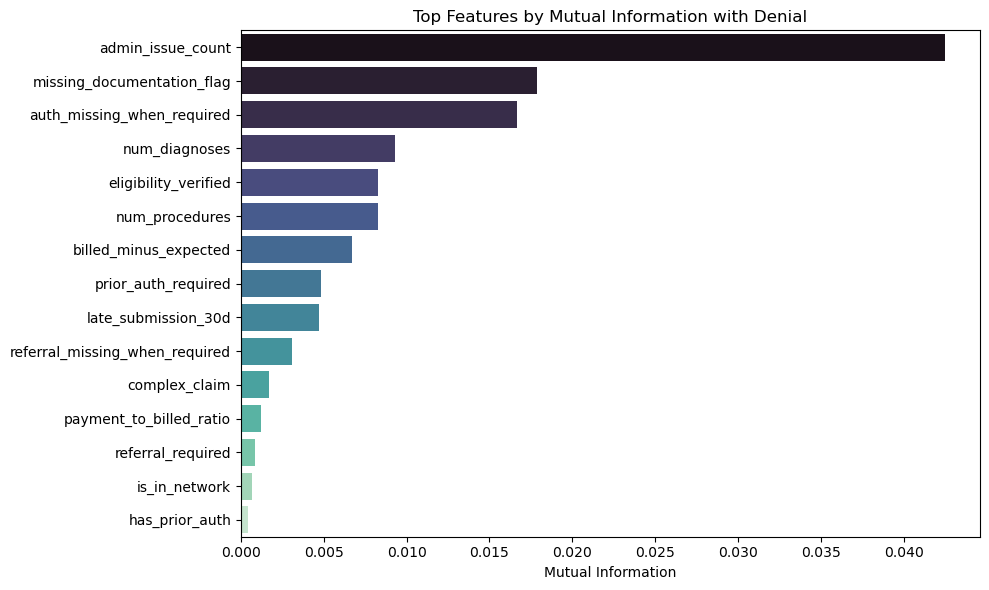

,feature,correlation,abs_correlation,single_feature_auc,auc_strength,mutual_info
18,admin_issue_count,0.293377,0.293377,0.668646,0.668646,0.042467
3,missing_documentation_flag,0.199079,0.199079,0.594662,0.594662,0.017871
7,auth_missing_when_required,0.197859,0.197859,0.571116,0.571116,0.016646
14,num_diagnoses,0.069002,0.069002,0.545213,0.545213,0.009277
4,eligibility_verified,-0.135636,0.135636,0.444345,0.555655,0.008290
13,num_procedures,0.078625,0.078625,0.542349,0.542349,0.008280
17,billed_minus_expected,0.101599,0.101599,0.575176,0.575176,0.006712
0,prior_auth_required,0.099231,0.099231,0.558529,0.558529,0.004839
9,late_submission_30d,0.100284,0.100284,0.544955,0.544955,0.004690
8,referral_missing_when_required,0.082248,0.082248,0.527354,0.527354,0.003079


In [7]:
def prepare_visualization_data(history_df):
    """
    Prepare history data for visual analysis.

    Coerces numeric fields, adds engineered features, and returns feature groups.
    """
    df = history_df.copy()

    categorical_cols = [
        "payer_id",
        "payer_type",
        "visit_type",
        "service_month",
    ]

    excluded_cols = {
        "claim_id",
        "split",
        "is_denied",
        "denial_reason",
    }

    feature_cols = [
        col for col in df.columns
        if col not in excluded_cols
    ]

    for col in feature_cols:
        if col not in categorical_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = add_engineered_features(df)

    binary_cols = [
        "prior_auth_required",
        "has_prior_auth",
        "is_in_network",
        "missing_documentation_flag",
        "eligibility_verified",
        "referral_required",
        "referral_present",
        "auth_missing_when_required",
        "referral_missing_when_required",
        "late_submission_30d",
        "complex_claim",
    ]

    continuous_cols = [
        "total_billed",
        "expected_payment",
        "num_procedures",
        "num_diagnoses",
        "days_to_submit",
        "payment_to_billed_ratio",
        "billed_minus_expected",
        "admin_issue_count",
    ]

    return df, categorical_cols, binary_cols, continuous_cols

def plot_target_distribution(df, target_col="is_denied"):
    """
    Plot overall denial distribution.
    """
    plt.figure(figsize=(5, 4))

    ax = sns.countplot(
        data=df,
        x=target_col,
        hue=target_col,
        palette="Set2",
        legend=False,
    )

    total = len(df)

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{int(v.get_height())}\n{v.get_height() / total:.1%}"
                for v in container
            ],
        )

    plt.title("Target Distribution")
    plt.xlabel("Denied")
    plt.ylabel("Claim Count")
    plt.tight_layout()
    plt.show()

def plot_denial_rate_by_category(
    df,
    col,
    target_col="is_denied",
    min_count=20,
    top_n=None,
):
    """
    Plot denial rate by a categorical or binary feature.

    Useful for payer, visit type, service month, and engineered binary flags.
    """
    summary = (
        df.groupby(col)[target_col]
        .agg(["count", "mean"])
        .reset_index()
    )

    summary = summary[summary["count"] >= min_count]
    summary = summary.sort_values("mean", ascending=False)

    if top_n is not None:
        summary = summary.head(top_n)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=summary,
        x=col,
        y="mean",
        hue=col,
        palette="viridis",
        legend=False,
    )

    overall_rate = df[target_col].mean()
    plt.axhline(
        overall_rate,
        color="red",
        linestyle="--",
        label=f"Overall denial rate: {overall_rate:.1%}",
    )

    plt.title(f"Denial Rate by {col}")
    plt.ylabel("Denial Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

def plot_denial_rate_by_numeric_bins(
    df,
    col,
    target_col="is_denied",
    bins=5,
):
    """
    Bin a continuous feature and plot denial rate by bin.

    This is better than a scatterplot because the target is binary.
    """
    temp_df = df[[col, target_col]].dropna().copy()

    temp_df["bin"] = pd.qcut(
        temp_df[col],
        q=bins,
        duplicates="drop",
    )

    summary = (
        temp_df.groupby("bin", observed=True)[target_col]
        .agg(["count", "mean"])
        .reset_index()
    )

    summary["bin_label"] = summary["bin"].astype(str)

    plt.figure(figsize=(10, 5))

    sns.lineplot(
        data=summary,
        x="bin_label",
        y="mean",
        marker="o",
    )

    overall_rate = df[target_col].mean()
    plt.axhline(
        overall_rate,
        color="red",
        linestyle="--",
        label=f"Overall denial rate: {overall_rate:.1%}",
    )

    plt.title(f"Denial Rate by Binned {col}")
    plt.ylabel("Denial Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

def plot_numeric_distribution_by_target(df, col, target_col="is_denied"):
    """
    Compare numeric feature distributions for denied vs not denied claims.
    """
    plt.figure(figsize=(9, 5))

    sns.kdeplot(
        data=df,
        x=col,
        hue=target_col,
        common_norm=False,
        fill=True,
        alpha=0.35,
    )

    plt.title(f"{col} Distribution by Denial Outcome")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

def plot_categorical_interaction_heatmap(
    df,
    row_col,
    col_col,
    target_col="is_denied",
    min_count=20,
):
    """
    Plot denial rate for two interacting categorical/binary features.

    Useful examples:
    - payer_type x admin_issue_count
    - visit_type x admin_issue_count
    - payer_type x auth_missing_when_required
    """
    grouped = (
        df.groupby([row_col, col_col])[target_col]
        .agg(["count", "mean"])
        .reset_index()
    )

    grouped.loc[grouped["count"] < min_count, "mean"] = np.nan

    heatmap_data = grouped.pivot(
        index=row_col,
        columns=col_col,
        values="mean",
    )

    plt.figure(figsize=(10, 5))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1%",
        cmap="Reds",
        linewidths=0.5,
    )

    plt.title(f"Denial Rate: {row_col} x {col_col}")
    plt.ylabel(row_col)
    plt.xlabel(col_col)
    plt.tight_layout()
    plt.show()

    return grouped

def calculate_feature_signal_table(
    df,
    numeric_cols,
    target_col="is_denied",
):
    """
    Calculate correlation, single-feature AUC strength, and mutual information.

    This helps decide whether visual patterns are statistically meaningful.
    """
    signal_df = df[numeric_cols].copy()
    y = df[target_col].astype(int)

    signal_df = signal_df.fillna(signal_df.median(numeric_only=True))

    rows = []

    for col in signal_df.columns:
        corr = signal_df[col].corr(y)

        try:
            auc = roc_auc_score(y, signal_df[col])
            auc_strength = max(auc, 1 - auc)
        except ValueError:
            auc = np.nan
            auc_strength = np.nan

        rows.append({
            "feature": col,
            "correlation": corr,
            "abs_correlation": abs(corr),
            "single_feature_auc": auc,
            "auc_strength": auc_strength,
        })

    signal_summary = pd.DataFrame(rows)

    discrete_features = [
        signal_df[col].nunique() <= 10
        for col in signal_df.columns
    ]

    mi_values = mutual_info_classif(
        signal_df,
        y,
        discrete_features=discrete_features,
        random_state=42,
    )

    mi_summary = pd.DataFrame({
        "feature": signal_df.columns,
        "mutual_info": mi_values,
    })

    signal_summary = signal_summary.merge(
        mi_summary,
        on="feature",
        how="left",
    )

    signal_summary = signal_summary.sort_values(
        by=["mutual_info", "abs_correlation", "auc_strength"],
        ascending=False,
    )

    return signal_summary

def plot_feature_signal_summary(signal_summary, top_n=15):
    """
    Plot top features by mutual information.
    """
    plot_df = signal_summary.head(top_n).copy()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_df,
        y="feature",
        x="mutual_info",
        hue="feature",
        palette="mako",
        legend=False,
    )

    plt.title("Top Features by Mutual Information with Denial")
    plt.xlabel("Mutual Information")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def run_visual_analysis(history_df):
    """
    Run a practical set of visualizations for feature-target understanding.
    """
    df, categorical_cols, binary_cols, continuous_cols = prepare_visualization_data(
        history_df
    )

    plot_target_distribution(df)

    for col in categorical_cols:
        plot_denial_rate_by_category(
            df=df,
            col=col,
            top_n=15,
        )

    for col in binary_cols:
        plot_denial_rate_by_category(
            df=df,
            col=col,
        )

    for col in continuous_cols:
        plot_denial_rate_by_numeric_bins(
            df=df,
            col=col,
            bins=5,
        )

    plot_categorical_interaction_heatmap(
        df=df,
        row_col="payer_type",
        col_col="admin_issue_count",
    )

    plot_categorical_interaction_heatmap(
        df=df,
        row_col="visit_type",
        col_col="admin_issue_count",
    )

    plot_categorical_interaction_heatmap(
        df=df,
        row_col="payer_type",
        col_col="auth_missing_when_required",
    )

    signal_summary = calculate_feature_signal_table(
        df=df,
        numeric_cols=binary_cols + continuous_cols,
    )

    plot_feature_signal_summary(signal_summary)

    return df, signal_summary

history_df = pd.read_csv("claims_history.csv")

visual_df, signal_summary = run_visual_analysis(history_df)

display(signal_summary)

In [8]:
def split_history_data(history_df, feature_cols, target_col="is_denied"):
    """
    Using the assignment-provided train/validation/test split exactly as given.
    """
    train_df = history_df[history_df["split"] == "train"].copy()
    valid_df = history_df[history_df["split"] == "validation"].copy()
    test_df = history_df[history_df["split"] == "test"].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    return X_train, y_train, X_valid, y_valid, X_test, y_test

In [9]:
def identify_column_types(feature_cols):
    """
    Use explicit column lists instead of relying only on pandas dtypes.
    """
    categorical_cols = [
        col for col in feature_cols
        if col in CATEGORICAL_COLS
    ]

    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    return numeric_cols, categorical_cols

In [10]:
def build_preprocessor(numeric_cols, categorical_cols):
    """
    Build preprocessing pipeline.
    """
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_cols),
            ("categorical", categorical_pipeline, categorical_cols),
        ]
    )

    return preprocessor

In [11]:
def top25_capture_score(y_true, y_score):
    """
    RandomizedSearchCV scorer.

    Measures how many actual denials are captured in the top 25%
    highest-risk claims.
    """
    if len(np.asarray(y_score).shape) == 2:
        y_score = np.asarray(y_score)[:, 1]

    eval_df = pd.DataFrame({
        "actual": y_true,
        "score": y_score,
    }).sort_values("score", ascending=False)

    n_review = int(np.ceil(len(eval_df) * 0.25))
    reviewed_df = eval_df.head(n_review)

    total_denials = eval_df["actual"].sum()

    if total_denials == 0:
        return 0.0

    return reviewed_df["actual"].sum() / total_denials

In [12]:
def build_candidate_models(
    preprocessor,
    X_train,
    y_train,
    n_iter=25,
    cv_splits=3,
    random_state=42,
):
    """
    Tune each candidate algorithm with RandomizedSearchCV and return the best
    fitted model object for each algorithm.

    The search optimizes the business metric:
    denial capture in the top 25% highest-risk claims.
    """
    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()
    scale_pos_weight = negative_count / positive_count

    scoring = {
        "top25_capture": make_scorer(
            top25_capture_score,
            response_method="predict_proba",
        ),
        "pr_auc": "average_precision",
        "roc_auc": "roc_auc",
    }

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state,
    )

    model_search_spaces = {
        "logistic_regression": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    ("model", LogisticRegression(
                        max_iter=2000,
                        random_state=random_state,
                    )),
                ]
            ),
            "params": {
                "model__C": loguniform(0.03, 5.0),
                "model__class_weight": [None, "balanced"],
            },
        },

        "random_forest": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    ("model", RandomForestClassifier(
                        random_state=random_state,
                        n_jobs=-1,
                    )),
                ]
            ),
            "params": {
                "model__n_estimators": randint(200, 700),
                "model__max_depth": [5, 8, 12, 16, None],
                "model__min_samples_leaf": randint(5, 50),
                "model__min_samples_split": randint(2, 30),
                "model__class_weight": ["balanced", "balanced_subsample", None],
            },
        },

        "hist_gradient_boosting": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    ("model", HistGradientBoostingClassifier(
                        random_state=random_state,
                    )),
                ]
            ),
            "params": {
                "model__max_iter": randint(75, 400),
                "model__learning_rate": loguniform(0.02, 0.12),
                "model__max_leaf_nodes": randint(8, 40),
                "model__l2_regularization": loguniform(0.01, 5.0),
                "model__min_samples_leaf": randint(10, 80),
            },
        },

        "xgboost": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    ("model", XGBClassifier(
                        objective="binary:logistic",
                        eval_metric="logloss",
                        random_state=random_state,
                        n_jobs=-1,
                    )),
                ]
            ),
            "params": {
                "model__n_estimators": randint(100, 500),
                "model__max_depth": randint(2, 6),
                "model__learning_rate": loguniform(0.02, 0.12),
                "model__min_child_weight": randint(1, 8),
                "model__subsample": uniform(0.7, 0.3),
                "model__colsample_bytree": uniform(0.7, 0.3),
                "model__reg_lambda": loguniform(0.5, 8.0),
                "model__scale_pos_weight": [1.0, scale_pos_weight],
            },
        },
    }

    best_models = {}
    search_summaries = []

    for model_name, search_config in model_search_spaces.items():
        print(f"\nRunning RandomizedSearchCV for {model_name}...")

        search = RandomizedSearchCV(
            estimator=search_config["pipeline"],
            param_distributions=search_config["params"],
            n_iter=n_iter,
            scoring=scoring,
            refit="top25_capture",
            cv=cv,
            random_state=random_state,
            n_jobs=-1,
            verbose=1,
            return_train_score=True,
        )

        search.fit(X_train, y_train)

        best_models[model_name] = search.best_estimator_

        search_summaries.append({
            "model": model_name,
            "best_cv_top25_capture": search.best_score_,
            "best_params": search.best_params_,
        })

        print(f"Best CV top-25 capture: {search.best_score_:.4f}")
        print(f"Best params: {search.best_params_}")

    search_summary_df = pd.DataFrame(search_summaries)

    print("\nRandomized search summary:")
    display(search_summary_df)

    return best_models

In [13]:
def calculate_top_quartile_capture(y_true, y_proba, review_fraction=0.25):
    """
    Calculate how many actual denials are captured in the highest-risk claims.

    This directly matches the business constraint:
    the team can only review the top 25% by risk score.
    """
    eval_df = pd.DataFrame({
        "actual": y_true.values,
        "proba": y_proba,
    })

    eval_df = eval_df.sort_values("proba", ascending=False)

    n_review = int(np.ceil(len(eval_df) * review_fraction))
    reviewed_df = eval_df.head(n_review)

    total_denials = eval_df["actual"].sum()
    captured_denials = reviewed_df["actual"].sum()

    capture_rate = captured_denials / total_denials if total_denials > 0 else 0
    precision_at_review = captured_denials / n_review if n_review > 0 else 0

    base_denial_rate = eval_df["actual"].mean()
    lift = precision_at_review / base_denial_rate if base_denial_rate > 0 else 0

    return {
        "review_fraction": review_fraction,
        "claims_reviewed": n_review,
        "total_denials": int(total_denials),
        "captured_denials": int(captured_denials),
        "denial_capture_rate": capture_rate,
        "precision_in_reviewed_claims": precision_at_review,
        "base_denial_rate": base_denial_rate,
        "lift_vs_base_rate": lift,
    }

In [14]:
def evaluate_model(model, X, y, threshold=0.5, review_fraction=0.25):
    """
    Evaluate model using both standard ML metrics and business-focused ranking metrics.
    """
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "threshold": threshold,
    }

    top_quartile_metrics = calculate_top_quartile_capture(
        y_true=y,
        y_proba=y_proba,
        review_fraction=review_fraction,
    )

    metrics.update(top_quartile_metrics)

    return metrics, y_proba, y_pred

In [15]:
def train_and_compare_models(models, X_train, y_train, X_valid, y_valid):
    """
    Train all candidate models and compare them on validation data.

    We select primarily by denial capture at top 25%, then PR-AUC as a tie-breaker.
    """
    results = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        metrics, _, _ = evaluate_model(
            model=model,
            X=X_valid,
            y=y_valid,
            threshold=0.5,
            review_fraction=0.25,
        )

        results[model_name] = {
            "model": model,
            "metrics": metrics,
        }

    comparison_df = pd.DataFrame({
        model_name: result["metrics"]
        for model_name, result in results.items()
    }).T

    comparison_df = comparison_df.sort_values(
        by=["denial_capture_rate", "pr_auc"],
        ascending=False,
    )

    best_model_name = comparison_df.index[0]
    best_model = results[best_model_name]["model"]

    return best_model_name, best_model, comparison_df, results

In [16]:
def choose_operational_threshold(model, X_valid, review_fraction=0.25):
    """
    Choose the risk threshold from validation scores.

    Since analysts can review only the top 25%, the threshold is the score
    at the 75th percentile. Claims above this are predicted_denial = 1.
    """
    valid_proba = model.predict_proba(X_valid)[:, 1]

    threshold = np.quantile(valid_proba, 1 - review_fraction)

    return threshold

In [17]:
def assign_risk_tier(probability, high_threshold, medium_threshold):
    """
    Convert probability into a simple analyst-friendly risk tier.
    """
    if probability >= high_threshold:
        return "High"
    elif probability >= medium_threshold:
        return "Medium"
    else:
        return "Low"

In [18]:
def choose_risk_tier_thresholds(model, X_valid):
    """
    Define risk tiers using validation score distribution.

    High: top 25%
    Medium: next 25%
    Low: bottom 50%
    """
    valid_proba = model.predict_proba(X_valid)[:, 1]

    high_threshold = np.quantile(valid_proba, 0.75)
    medium_threshold = np.quantile(valid_proba, 0.50)

    return high_threshold, medium_threshold

In [19]:
def get_feature_names_from_pipeline(model):
    """
    Extract transformed feature names from the fitted preprocessing pipeline.
    Useful for feature importance and explanation support.
    """
    preprocessor = model.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    return feature_names

In [20]:
def get_global_feature_importance(model):
    """
    Return global feature importance if the model supports it.

    Tree-based models expose feature_importances_.
    Logistic regression exposes coefficients.
    """
    fitted_model = model.named_steps["model"]
    feature_names = get_feature_names_from_pipeline(model)

    if hasattr(fitted_model, "feature_importances_"):
        importance_values = fitted_model.feature_importances_

    elif hasattr(fitted_model, "coef_"):
        importance_values = np.abs(fitted_model.coef_[0])

    else:
        return pd.DataFrame(columns=["feature", "importance"])

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False,
    )

    return importance_df

In [21]:
def humanize_feature_name(feature_name):
    """
    Make transformed feature names easier to read in output files.

    Example:
    categorical__payer_type_Medicaid MCO -> payer_type = Medicaid MCO
    numeric__days_to_submit -> days_to_submit
    """
    clean_name = feature_name.replace("numeric__", "").replace("categorical__", "")

    return clean_name

In [22]:
def infer_claim_risk_factors(row):
    """
    Generate simple, grounded claim-level risk factors from actual field values.

    This is intentionally rule-based so explanations do not invent model logic.
    Later, we can replace or supplement this with SHAP if desired.
    """
    factors = []

    if row.get("missing_documentation_flag", 0) == 1:
        factors.append("missing documentation")

    if row.get("eligibility_verified", 1) == 0:
        factors.append("eligibility not verified")

    if row.get("auth_missing_when_required", 0) == 1:
        factors.append("prior authorization required but not on file")

    if row.get("referral_missing_when_required", 0) == 1:
        factors.append("referral required but not present")

    if row.get("is_in_network", 1) == 0:
        factors.append("provider is out of network")

    if row.get("late_submission_30d", 0) == 1:
        factors.append("claim submitted 30 or more days after service")

    if row.get("payment_to_billed_ratio", 1) < 0.4:
        factors.append("low expected payment compared with billed amount")

    if row.get("complex_claim", 0) == 1:
        factors.append("complex claim with many procedures or diagnoses")

    if row.get("admin_issue_count", 0) >= 3:
        factors.append("multiple administrative risk issues")

    if len(factors) == 0:
        factors.append("overall claim pattern similar to previously denied claims")

    return factors[:3]

In [23]:
def build_llm_prompt_for_claim(claim_row, denial_probability, top_risk_factors):
    """
    Build the LLM prompt for a single claim explanation.

    The prompt explicitly restricts the model to the supplied data.
    """
    prompt = f"""
You are helping a hospital claims analyst review denial risk before claim submission.

Write a short explanation for the claim below.

Rules:
- Use only the claim fields and risk factors provided.
- Do not invent facts.
- Use plain English.
- Mention that this is a risk estimate, not a guaranteed denial.
- Include one specific recommended action.
- Keep the explanation to 2-3 sentences.

Claim ID: {claim_row["claim_id"]}
Predicted denial probability: {denial_probability:.3f}

Key risk factors:
{", ".join(top_risk_factors)}

Claim fields:
payer_id: {claim_row.get("payer_id")}
payer_type: {claim_row.get("payer_type")}
visit_type: {claim_row.get("visit_type")}
total_billed: {claim_row.get("total_billed")}
expected_payment: {claim_row.get("expected_payment")}
num_procedures: {claim_row.get("num_procedures")}
num_diagnoses: {claim_row.get("num_diagnoses")}
prior_auth_required: {claim_row.get("prior_auth_required")}
has_prior_auth: {claim_row.get("has_prior_auth")}
is_in_network: {claim_row.get("is_in_network")}
days_to_submit: {claim_row.get("days_to_submit")}
missing_documentation_flag: {claim_row.get("missing_documentation_flag")}
eligibility_verified: {claim_row.get("eligibility_verified")}
referral_required: {claim_row.get("referral_required")}
referral_present: {claim_row.get("referral_present")}
service_month: {claim_row.get("service_month")}
"""

    return prompt.strip()

In [24]:
from openai import OpenAI

def generate_openai_explanation(
    claim_row,
    denial_probability,
    top_risk_factors,
    api_key,
    model="gpt-5.5-medium",
):
    """
    Generate a grounded claim-risk explanation using OpenAI.

    The function uses the existing build_llm_prompt_for_claim() prompt template.
    If the API call fails, it falls back to the manual explanation so the
    end-to-end scoring flow does not break.
    """
    prompt = build_llm_prompt_for_claim(
        claim_row=claim_row,
        denial_probability=denial_probability,
        top_risk_factors=top_risk_factors,
    )

    client = OpenAI(api_key=api_key)

    try:
        response = client.responses.create(
            model=model,
            input=[
                {
                    "role": "system",
                    "content": (
                        "You write concise, factual explanations for healthcare "
                        "claims analysts. Use only the provided claim data. "
                        "Do not invent facts."
                    ),
                },
                {
                    "role": "user",
                    "content": prompt,
                },
            ],
            max_output_tokens=160,
        )

        explanation = response.output_text.strip()

        return explanation

    except Exception as error:
        print(
            f"OpenAI explanation failed for claim {claim_row.get('claim_id')}: {error}"
        )

        return create_manual_explanation(
            claim_row=claim_row,
            denial_probability=denial_probability,
            top_risk_factors=top_risk_factors,
        )

In [25]:
def create_manual_explanation(claim_row, denial_probability, top_risk_factors):
    """
    Fallback explanation generator if no LLM API is available.

    This keeps the output grounded and acceptable for the assignment if API access
    is not used.
    """
    factor_text = ", ".join(top_risk_factors)

    if len(top_risk_factors) == 1:
        factor_text = top_risk_factors[0]

    explanation = (
        f"This claim has an estimated denial risk of {denial_probability:.1%}, "
        f"mainly because of {factor_text}. "
        f"This is a risk estimate, not a guarantee of denial; before submission, "
        f"review these items and correct or document them where possible."
    )

    return explanation

In [26]:
def score_current_claims(
    model,
    current_df,
    feature_cols,
    threshold,
    high_threshold,
    medium_threshold,
    use_openai_explanations=False,
    openai_api_key=None,
    openai_model="gpt-5.5-medium",
    llm_explanation_top_n=10,
):
    """
    Score current claims and generate explanations.

    If use_openai_explanations=True and openai_api_key is provided, the top N
    highest-risk claims get OpenAI-generated explanations.

    All other claims receive the manual fallback explanation.
    """
    scored_df = current_df.copy()

    scored_df["denial_probability"] = model.predict_proba(
        scored_df[feature_cols]
    )[:, 1]

    scored_df["predicted_denial"] = (
        scored_df["denial_probability"] >= threshold
    ).astype(int)

    scored_df["risk_tier"] = scored_df["denial_probability"].apply(
        lambda p: assign_risk_tier(
            probability=p,
            high_threshold=high_threshold,
            medium_threshold=medium_threshold,
        )
    )

    scored_df = scored_df.sort_values(
        "denial_probability",
        ascending=False,
    )

    top_risk_factors_list = []
    explanation_list = []
    prompt_list = []

    top_llm_claim_ids = set(
        scored_df.head(llm_explanation_top_n)["claim_id"]
    )

    for _, row in scored_df.iterrows():
        factors = infer_claim_risk_factors(row)

        prompt = build_llm_prompt_for_claim(
            claim_row=row,
            denial_probability=row["denial_probability"],
            top_risk_factors=factors,
        )

        should_use_openai = (
            use_openai_explanations
            and openai_api_key is not None
            and row["claim_id"] in top_llm_claim_ids
        )

        if should_use_openai:
            explanation = generate_openai_explanation(
                claim_row=row,
                denial_probability=row["denial_probability"],
                top_risk_factors=factors,
                api_key=openai_api_key,
                model=openai_model,
            )
        else:
            explanation = create_manual_explanation(
                claim_row=row,
                denial_probability=row["denial_probability"],
                top_risk_factors=factors,
            )

        top_risk_factors_list.append("; ".join(factors))
        explanation_list.append(explanation)
        prompt_list.append(prompt)

    scored_df["top_risk_factors"] = top_risk_factors_list
    scored_df["explanation"] = explanation_list
    scored_df["llm_prompt"] = prompt_list

    required_cols = [
        "claim_id",
        "denial_probability",
        "predicted_denial",
        "risk_tier",
        "top_risk_factors",
        "explanation",
    ]

    return scored_df[required_cols], scored_df

In [41]:
def run_full_workflow(
    history_path,
    current_path,
    output_path,
    openai_api_key=None,
    openai_model="gpt-5.5-medium",
):
    """
    End-to-end workflow.

    Prints train, validation, and test comparison tables.

    Model selection uses:
    1. Higher validation denial_capture_rate
    2. Lower train-vs-validation denial_capture_rate generalization gap
    3. Higher validation PR-AUC
    4. Higher validation ROC-AUC

    Test metrics are reported only after model selection.
    """
    history_df, current_df = load_data(history_path, current_path)

    feature_cols = get_feature_columns(history_df)

    history_df = coerce_feature_types(history_df, feature_cols)
    current_df = coerce_feature_types(current_df, feature_cols)

    history_df = add_engineered_features(history_df)
    current_df = add_engineered_features(current_df)

    feature_cols = get_feature_columns(history_df)

    X_train, y_train, X_valid, y_valid, X_test, y_test = split_history_data(
        history_df=history_df,
        feature_cols=feature_cols,
    )

    numeric_cols, categorical_cols = identify_column_types(feature_cols)

    preprocessor = build_preprocessor(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
    )

    models = build_candidate_models(
        preprocessor=preprocessor,
        X_train=X_train,
        y_train=y_train,
        n_iter=25,
        cv_splits=3,
        random_state=42,
    )

    trained_results = {}
    train_comparison = {}
    validation_comparison = {}
    test_comparison = {}
    model_selection_rows = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        model_valid_threshold = choose_operational_threshold(
            model=model,
            X_valid=X_valid,
            review_fraction=0.25,
        )

        train_metrics, _, _ = evaluate_model(
            model=model,
            X=X_train,
            y=y_train,
            threshold=model_valid_threshold,
            review_fraction=0.25,
        )

        validation_metrics, _, _ = evaluate_model(
            model=model,
            X=X_valid,
            y=y_valid,
            threshold=model_valid_threshold,
            review_fraction=0.25,
        )

        test_metrics, _, _ = evaluate_model(
            model=model,
            X=X_test,
            y=y_test,
            threshold=model_valid_threshold,
            review_fraction=0.25,
        )

        train_capture = train_metrics["denial_capture_rate"]
        validation_capture = validation_metrics["denial_capture_rate"]

        train_validation_generalization_gap = abs(
            train_capture - validation_capture
        )

        trained_results[model_name] = {
            "model": model,
            "train_metrics": train_metrics,
            "validation_metrics": validation_metrics,
            "test_metrics": test_metrics,
            "train_validation_generalization_gap": train_validation_generalization_gap,
        }

        train_comparison[model_name] = train_metrics
        validation_comparison[model_name] = validation_metrics
        test_comparison[model_name] = test_metrics

        model_selection_rows[model_name] = {
            **validation_metrics,
            "train_denial_capture_rate": train_capture,
            "validation_denial_capture_rate": validation_capture,
            "train_validation_generalization_gap": train_validation_generalization_gap,
        }

    train_comparison = pd.DataFrame(train_comparison).T
    validation_comparison = pd.DataFrame(validation_comparison).T
    test_comparison = pd.DataFrame(test_comparison).T
    model_selection_comparison = pd.DataFrame(model_selection_rows).T

    model_selection_comparison = model_selection_comparison.sort_values(
        by=["train_validation_generalization_gap",
            "denial_capture_rate",
            "pr_auc",
            "roc_auc",
        ],
        ascending=[
            True,
            True,
            False,
            False,
        ],
    )

    validation_comparison = validation_comparison.loc[
        model_selection_comparison.index
    ]
    train_comparison = train_comparison.loc[
        model_selection_comparison.index
    ]
    test_comparison = test_comparison.loc[
        model_selection_comparison.index
    ]

    best_model_name = model_selection_comparison.index[1]
    best_model = trained_results[best_model_name]["model"]

    threshold = choose_operational_threshold(
        model=best_model,
        X_valid=X_valid,
        review_fraction=0.25,
    )

    high_threshold, medium_threshold = choose_risk_tier_thresholds(
        model=best_model,
        X_valid=X_valid,
    )

    final_test_metrics, test_proba, test_pred = evaluate_model(
        model=best_model,
        X=X_test,
        y=y_test,
        threshold=threshold,
        review_fraction=0.25,
    )

    predictions_df, scored_full_df = score_current_claims(
        model=best_model,
        current_df=current_df,
        feature_cols=feature_cols,
        threshold=threshold,
        high_threshold=high_threshold,
        medium_threshold=medium_threshold,
        use_openai_explanations=False,
        openai_api_key=openai_api_key,
        openai_model=openai_model,
        llm_explanation_top_n=10,
    )

    predictions_df.to_csv(output_path, index=False)

    print("Best model:", best_model_name)
    print("\nOperational threshold:", threshold)
    print("High risk threshold:", high_threshold)
    print("Medium risk threshold:", medium_threshold)

    print("\nModel selection comparison:")
    display(model_selection_comparison)

    print("\nValidation comparison:")
    display(validation_comparison)

    print("\nTrain comparison:")
    display(train_comparison)

    print("\nTest comparison:")
    display(test_comparison)

    return {
        "best_model_name": best_model_name,
        "best_model": best_model,
        "model_selection_comparison": model_selection_comparison,
        "validation_comparison": validation_comparison,
        "train_comparison": train_comparison,
        "test_comparison": test_comparison,
        "test_metrics": final_test_metrics,
        "threshold": threshold,
        "high_threshold": high_threshold,
        "medium_threshold": medium_threshold,
        "predictions": predictions_df,
        "scored_full": scored_full_df,
    }

In [44]:
results = run_full_workflow(
    history_path="claims_history.csv",
    current_path="current_claims.csv",
    output_path="predictions_current_claims.csv",
)


print("\nTop 10 current claims:")
display(results["predictions"].head(10))


Running RandomizedSearchCV for logistic_regression...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best CV top-25 capture: 0.4956
Best params: {'model__C': np.float64(0.14253679092944802), 'model__class_weight': None}

Running RandomizedSearchCV for random_forest...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best CV top-25 capture: 0.4956
Best params: {'model__class_weight': None, 'model__max_depth': 16, 'model__min_samples_leaf': 33, 'model__min_samples_split': 16, 'model__n_estimators': 306}

Running RandomizedSearchCV for hist_gradient_boosting...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best CV top-25 capture: 0.4666
Best params: {'model__l2_regularization': np.float64(1.519988122008397), 'model__learning_rate': np.float64(0.03451958620131221), 'model__max_iter': 127, 'model__max_leaf_nodes': 9, 'model__min_samples_leaf': 69}

Running RandomizedSearchCV for xgboost...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

,model,best_cv_top25_capture,best_params
0,logistic_regression,0.495630,"{'model__C': 0.14253679092944802, 'model__clas..."
1,random_forest,0.495630,"{'model__class_weight': None, 'model__max_dept..."
2,hist_gradient_boosting,0.466622,{'model__l2_regularization': 1.519988122008397...
3,xgboost,0.466637,{'model__colsample_bytree': 0.9313811040057837...


Best model: logistic_regression

Operational threshold: 0.2784927701011247
High risk threshold: 0.2784927701011247
Medium risk threshold: 0.15935884392332608

Model selection comparison:


,roc_auc,pr_auc,precision,recall,f1,threshold,review_fraction,claims_reviewed,total_denials,captured_denials,denial_capture_rate,precision_in_reviewed_claims,base_denial_rate,lift_vs_base_rate,train_denial_capture_rate,validation_denial_capture_rate,train_validation_generalization_gap
logistic_regression,0.704596,0.457769,0.377778,0.495146,0.428571,0.278493,0.25,135.0,103.0,51.0,0.495146,0.377778,0.191095,1.976915,0.513393,0.495146,0.018247
random_forest,0.693061,0.417449,0.385185,0.504854,0.436975,0.274279,0.25,135.0,103.0,52.0,0.504854,0.385185,0.191095,2.015678,0.549107,0.504854,0.044253
hist_gradient_boosting,0.688986,0.415750,0.362963,0.475728,0.411765,0.286076,0.25,135.0,103.0,49.0,0.475728,0.362963,0.191095,1.899389,0.591518,0.475728,0.115790
xgboost,0.686314,0.394616,0.355556,0.466019,0.403361,0.266661,0.25,135.0,103.0,48.0,0.466019,0.355556,0.191095,1.860626,0.582589,0.466019,0.116570



Validation comparison:


...

,roc_auc,pr_auc,precision,recall,f1,threshold,review_fraction,claims_reviewed,total_denials,captured_denials,denial_capture_rate,precision_in_reviewed_claims,base_denial_rate,lift_vs_base_rate
logistic_regression,0.741853,0.482332,0.438735,0.495536,0.465409,0.278493,0.25,531.0,448.0,230.0,0.513393,0.433145,0.211122,2.051638
random_forest,0.787612,0.533663,0.469636,0.517857,0.492569,0.274279,0.25,531.0,448.0,246.0,0.549107,0.463277,0.211122,2.194360
hist_gradient_boosting,0.810868,0.585827,0.520408,0.569196,0.543710,0.286076,0.25,531.0,448.0,265.0,0.591518,0.499058,0.211122,2.363843
xgboost,0.803298,0.597785,0.504931,0.571429,0.536126,0.266661,0.25,531.0,448.0,261.0,0.582589,0.491525,0.211122,2.328163



Test comparison:


,roc_auc,pr_auc,precision,recall,f1,threshold,review_fraction,claims_reviewed,total_denials,captured_denials,denial_capture_rate,precision_in_reviewed_claims,base_denial_rate,lift_vs_base_rate
logistic_regression,0.689492,0.509974,0.482014,0.478571,0.480287,0.278493,0.25,135.0,140.0,64.0,0.457143,0.474074,0.25974,1.825185
random_forest,0.690691,0.513006,0.446809,0.450000,0.448399,0.274279,0.25,135.0,140.0,63.0,0.450000,0.466667,0.25974,1.796667
hist_gradient_boosting,0.672735,0.505527,0.441860,0.407143,0.423792,0.286076,0.25,135.0,140.0,57.0,0.407143,0.422222,0.25974,1.625556
xgboost,0.679395,0.509197,0.426471,0.414286,0.420290,0.266661,0.25,135.0,140.0,58.0,0.414286,0.429630,0.25974,1.654074



Top 10 current claims:


,claim_id,denial_probability,predicted_denial,risk_tier,top_risk_factors,explanation
81,CCLM-00082,0.807575,1,High,missing documentation; eligibility not verifie...,This claim has an estimated denial risk of 80....
86,CCLM-00087,0.800567,1,High,missing documentation; eligibility not verifie...,This claim has an estimated denial risk of 80....
371,CCLM-00372,0.741121,1,High,missing documentation; prior authorization req...,This claim has an estimated denial risk of 74....
48,CCLM-00049,0.708717,1,High,missing documentation; prior authorization req...,This claim has an estimated denial risk of 70....
343,CCLM-00344,0.697968,1,High,missing documentation; prior authorization req...,This claim has an estimated denial risk of 69....
135,CCLM-00136,0.680959,1,High,missing documentation; referral required but n...,This claim has an estimated denial risk of 68....
284,CCLM-00285,0.669590,1,High,missing documentation; prior authorization req...,This claim has an estimated denial risk of 67....
445,CCLM-00446,0.667267,1,High,missing documentation; eligibility not verifie...,This claim has an estimated denial risk of 66....
176,CCLM-00177,0.638910,1,High,missing documentation; prior authorization req...,This claim has an estimated denial risk of 63....
22,CCLM-00023,0.626677,1,High,missing documentation; prior authorization req...,This claim has an estimated denial risk of 62....


In [45]:
results["predictions"].head(10).to_csv('top_10.csv', index = False)